##1. Imports

In [4]:
#This cell is for Google Colab since both modules are not preinstalled
!pip install dice-ml
!pip install shap

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import dice_ml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Using the dataset as it is


### 2.1 Processing data and confusion matrix for analysis

In [6]:
# Load and preview dataset
df = pd.read_csv('synthetic_fraud_dataset.csv')
print(df.shape)
print(df['is_fraud'].value_counts())
df.head()

(10000, 10)
is_fraud
0    9500
1     500
Name: count, dtype: int64


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [7]:
# Drop irrelevant ID columns and encode categoricals
df = df.drop(columns=['transaction_id', 'user_id'])

cat_cols = ['transaction_type', 'merchant_category', 'country']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Split into features and target, then train/test split
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



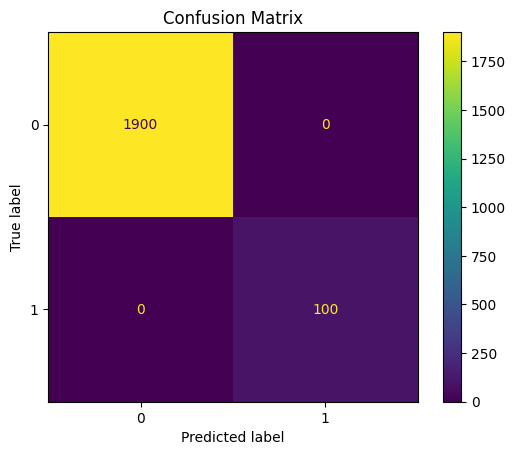

In [8]:
# Train Random Forest and evaluate
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

cm = confusion_matrix(y_test, clf.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

### 2.2. SHAP Explanation and Plots

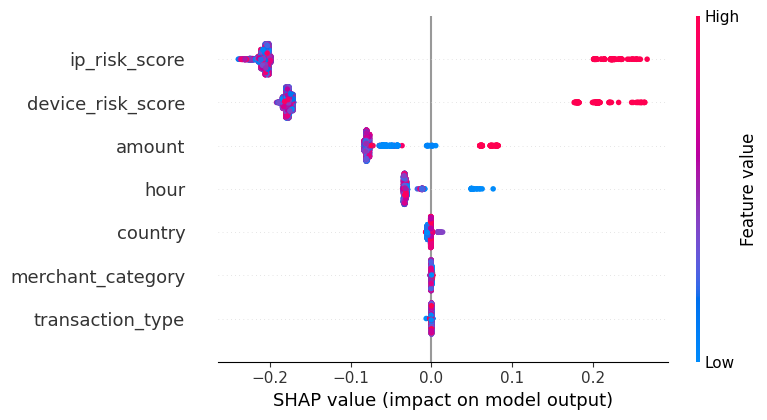

In [9]:
# SHAP global explanation to see which features drive fraud predictions overall
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

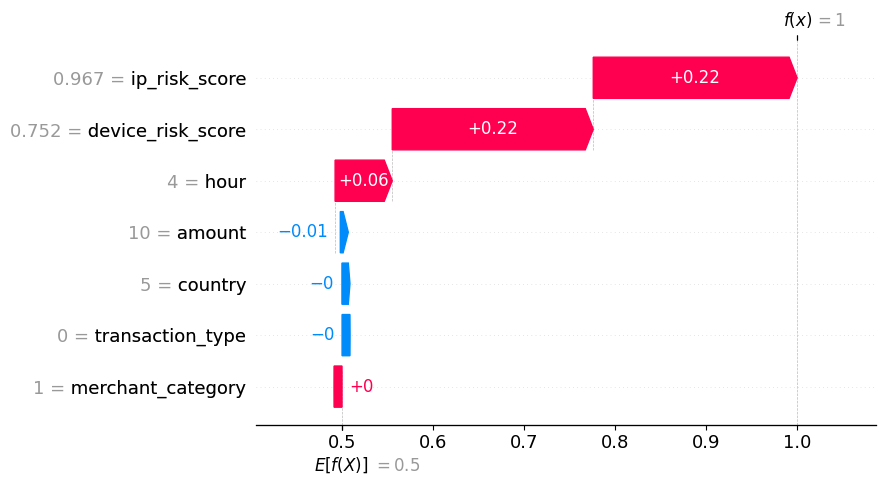

In [10]:
# SHAP local explanation to see why was this specific transaction flagged as fraud
fraud_idx = y_test[y_test == 1].index[0]
fraud_sample = X_test.loc[[fraud_idx]]

shap.waterfall_plot(
    shap.Explanation(
        values=explainer.shap_values(fraud_sample)[..., 1][0],
        base_values=explainer.expected_value[1],
        data=fraud_sample.iloc[0],
        feature_names=X.columns.tolist()
    )
)

### 2.3. DiCE Explanation

In [16]:
# DiCE counterfactuals — what would need to change to predict non-fraud
df_dice = X_train.copy().astype(float)
df_dice['is_fraud'] = y_train.values.astype(float)

data_interface = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=['amount', 'hour', 'device_risk_score', 'ip_risk_score',
                         'transaction_type', 'merchant_category', 'country'],
    outcome_name='is_fraud'
)
model_interface = dice_ml.Model(model=clf, backend='sklearn')
exp = dice_ml.Dice(data_interface, model_interface, method='random')

cf = exp.generate_counterfactuals(
    fraud_sample.astype(float),
    total_CFs=3,
    desired_class='opposite'
)

print("Original transaction:")
print(fraud_sample)
print("\nCounterfactuals (minimal changes to predict non-fraud):")
cf.visualize_as_dataframe()

# Encoding mappings for interpretation
for col in cat_cols:
    mapping = {k: int(v) for k, v in zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_))}
    print(f"{col}: {mapping}")

100%|██████████| 1/1 [00:01<00:00,  1.04s/it]

Original transaction:
     amount  transaction_type  merchant_category  country  hour  \
444    10.0                 0                  1        5     4   

     device_risk_score  ip_risk_score  
444           0.751845       0.967458  

Counterfactuals (minimal changes to predict non-fraud):
Query instance (original outcome : 1)


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,10.0,0.0,1.0,5.0,4.0,0.751845,0.967458,1



Diverse Counterfactual set (new outcome: 0)


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,10.0,0.0,1.0,5.0,4.0,0.238381,0.237240,0
1,10.0,0.0,1.0,5.0,16.8,0.751845,0.454403,0
2,10.0,0.0,1.0,5.0,13.2,0.751845,0.249164,0


transaction_type: {'ATM': 0, 'Online': 1, 'POS': 2, 'QR': 3}
merchant_category: {'Clothing': 0, 'Electronics': 1, 'Food': 2, 'Grocery': 3, 'Travel': 4}
country: {'DE': 0, 'FR': 1, 'NG': 2, 'TR': 3, 'UK': 4, 'US': 5}


## 3. Using the noisy data

### 3.1. Re-processing the data and computing confusion matrix for analysis

Original model (with risk scores):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Reduced model (noise added to amount):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1900
           1       0.76      0.62      0.68       100

    accuracy                           0.97      2000
   macro avg       0.87      0.80      0.83      2000
weighted avg       0.97      0.97      0.97      2000



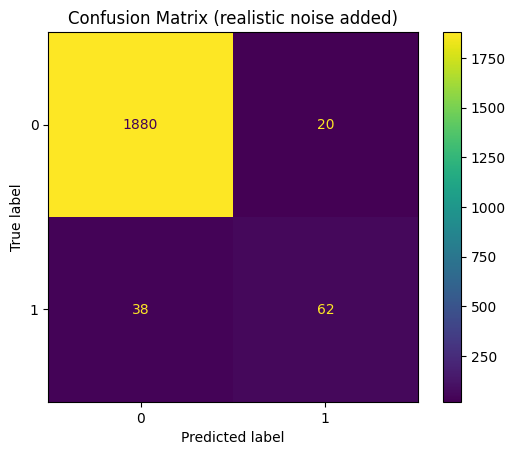

In [12]:
# Risk score features correlate too strongly with fraud (r=0.87), making the model trivially perfect.
# We drop them and add noise to 'amount' to simulate realistic class overlap.
np.random.seed(42)
X_noisy = X.drop(columns=['device_risk_score', 'ip_risk_score']).copy()
X_noisy['amount'] = X_noisy['amount'] + np.random.normal(0, 800, size=len(X_noisy))
X_noisy['amount'] = X_noisy['amount'].clip(lower=0)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain on reduced, noisier data
clf_reduced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf_reduced.fit(X_train_r, y_train_r)

print("Original model (with risk scores):")
print(classification_report(y_test, clf.predict(X_test)))

print("Reduced model (noise added to amount):")
print(classification_report(y_test_r, clf_reduced.predict(X_test_r)))

cm_r = confusion_matrix(y_test_r, clf_reduced.predict(X_test_r))
ConfusionMatrixDisplay(cm_r).plot()
plt.title("Confusion Matrix (realistic noise added)")
plt.show()

### 3.2 SHAP Explanation and Plots

/tmp/ipykernel_5654/1450153739.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_r[:, :, 1], X_test_r)


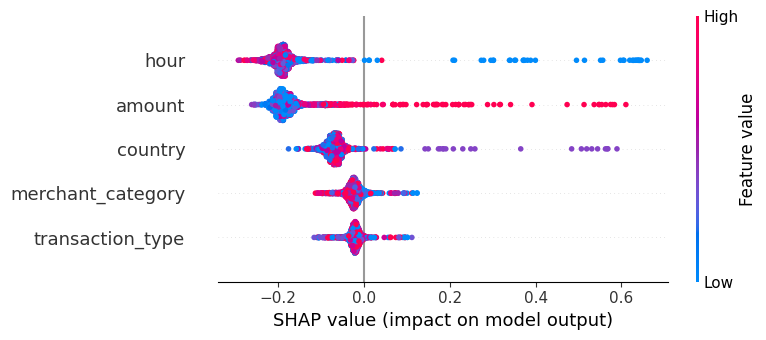

In [13]:
# SHAP global explanation to see which features drive fraud predictions overall
explainer_r = shap.TreeExplainer(clf_reduced)
shap_values_r = explainer_r.shap_values(X_test_r)

shap.summary_plot(shap_values_r[:, :, 1], X_test_r)

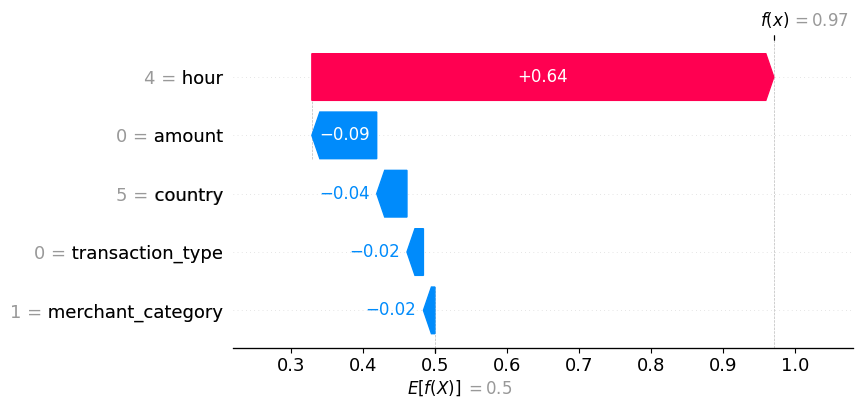

In [14]:
# SHAP local explanation to see why was this specific transaction flagged as fraud
fraud_idx_r = y_test_r[y_test_r == 1].index[0]
fraud_sample_r = X_test_r.loc[[fraud_idx_r]]

shap.waterfall_plot(
    shap.Explanation(
        values=explainer_r.shap_values(fraud_sample_r)[..., 1][0],
        base_values=explainer_r.expected_value[1],
        data=fraud_sample_r.iloc[0],
        feature_names=X_noisy.columns.tolist()
    )
)

### 3.3 DiCE Explanation

In [15]:
df_dice_r = X_train_r.copy().astype(float)
df_dice_r['is_fraud'] = y_train_r.values.astype(float)

data_interface_r = dice_ml.Data(
    dataframe=df_dice_r,
    continuous_features=['amount', 'hour', 'transaction_type', 'merchant_category', 'country'],
    outcome_name='is_fraud'
)
model_interface_r = dice_ml.Model(model=clf_reduced, backend='sklearn')
exp_r = dice_ml.Dice(data_interface_r, model_interface_r, method='random')

cf_r = exp_r.generate_counterfactuals(
    fraud_sample_r.astype(float),
    total_CFs=3,
    desired_class='opposite'
)

print("Original transaction:")
print(fraud_sample_r)
print("\nCounterfactuals (minimal changes to predict non-fraud):")
cf_r.visualize_as_dataframe()

# Encoding mappings for interpretation
for col in cat_cols:
    mapping = {k: int(v) for k, v in zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_))}
    print(f"{col}: {mapping}")

100%|██████████| 1/1 [00:00<00:00,  1.85it/s]

Original transaction:
     amount  transaction_type  merchant_category  country  hour
444     0.0                 0                  1        5     4

Counterfactuals (minimal changes to predict non-fraud):
Query instance (original outcome : 1)


,amount,transaction_type,merchant_category,country,hour,is_fraud
0,0.0,0.0,1.0,5.0,4.0,1



Diverse Counterfactual set (new outcome: 0)


,amount,transaction_type,merchant_category,country,hour,is_fraud
0,0.0,0.0,1.0,5.0,13.7,0
1,0.0,0.0,1.0,5.0,16.8,0
2,0.0,2.0,1.0,5.0,19.0,0


transaction_type: {'ATM': 0, 'Online': 1, 'POS': 2, 'QR': 3}
merchant_category: {'Clothing': 0, 'Electronics': 1, 'Food': 2, 'Grocery': 3, 'Travel': 4}
country: {'DE': 0, 'FR': 1, 'NG': 2, 'TR': 3, 'UK': 4, 'US': 5}
